#**Comparable Companies Analysis**

---



##**Table of Content:**

---





1. Project Objective
2. Project Overview
3. Import Libraries
4. Comparable Companies Dataset
5. Valuation Multiples
6. Peer Group Statistics
7. Target Company Selection
8. Implied Valuation
9. Valuation Summary
10. Valuation Multiple Comparison
11. Target vs. Peer Median
12. Valuation Analysis
13. Conclusion

## **Project Objective**

---





##This project performs a Comparable Companies Analysis (Comps) to compare companies within the same industry using key financial metrics and valuation multiples.




## **The analysis includes:**
- Revenue and EBITDA comparison
- Enterprise Value and Market Capitalization
- P/E, EV/EBITDA, and EV/Revenue multiples
- Peer group statistics
- Mean and median valuation multiples
- Implied valuation of a target company

## **Purpose**


## The goal is to understand how comparable company analysis is used in financial valuation and Investment Banking.




##**Project Overview**

---





Comparable Companies Analysis is a relative valuation method used to evaluate a company by comparing it with similar companies in the same industry.

In this project, five companies are analyzed using key financial metrics and valuation multiples. Alpha Ltd is selected as the target company, while the remaining companies form the peer group.

The analysis calculates:
- P/E (Price-to-Earnings)
- EV/EBITDA (Enterprise Value to EBITDA)
- EV/Revenue (Enterprise Value to Revenue)

The median peer multiples are then applied to the target company's financial metrics to estimate its implied valuation.

---



# **Step 1 - Import Libraries**

---



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

##**We are using :**


*   pandas → to create and analyze our company dataset
*   numpy → for numerical calculations
*   matplotlib → to create charts and visualize our analysis





# **Step 2 - Create Comparable Companies Dataset :**


---





## For this project, let's use **5 fictional but realistic companies** so we can focus on learning the valuation process without worrying about changing market data.

In [ ]:
data = {
    "Company" : [
        "Alpha Ltd",
        "Beta Ltd",
        "Gamma Ltd",
        "Delta Ltd",
        "Epsilon Ltd"
    ],
    "Revenue" :[
        5000,
        7500,
        6200,
        9000,
        6800
    ],
    "EBITDA" : [
        1200,
        1650,
        1400,
        2100,
        1500
    ],
    "Net Income" :[
        600,
        850,
        720,
        1100,
        780
    ],
    "Market Cap": [
        12000,
        18000,
        15000,
        24000,
        16500
    ],
    "Enterprise Value": [
        13500,
        19500,
        16500,
        26000,
        18000
    ]


}

df=pd.DataFrame(data)
df

,Company,Revenue,EBITDA,Net Income,Market Cap,Enterprise Value
0,Alpha Ltd,5000,1200,600,12000,13500
1,Beta Ltd,7500,1650,850,18000,19500
2,Gamma Ltd,6200,1400,720,15000,16500
3,Delta Ltd,9000,2100,1100,24000,26000
4,Epsilon Ltd,6800,1500,780,16500,18000


##**What this does**
We're creating a dataset containing :
| Metric           | Meaning                                                                       |
| ---------------- | ----------------------------------------------------------------------------- |
| Revenue          | Company's total sales                                                         |
| EBITDA           | Operating profitability before interest, taxes, depreciation and amortization |
| Net Income       | Profit after all expenses                                                     |
| Market Cap       | Market value of equity                                                        |
| Enterprise Value | Value of the entire operating business                                        |


#**Step 3 - Calculate Valuation Multiples**

---



## Now we'll calculate the three most important multiples in our Company's analysis:


*   **P/E (Price-to-Earnings)** = Market Cap ÷ Net Income
*   **EV/EBITDA** = Enterprise Value ÷ EBITDA


*   **EV/Revenue** = Enterprise Value ÷ Revenue


In [ ]:
df["P/E"] = df["Market Cap"]/df["Net Income"]
df["EV/EBITDA"]= df["Enterprise Value"]/df["EBITDA"]
df["EV/Revenue"]=df["Enterprise Value"]/df["Revenue"]
df

,Company,Revenue,EBITDA,Net Income,Market Cap,Enterprise Value,P/E,EV/EBITDA,EV/Revenue
0,Alpha Ltd,5000,1200,600,12000,13500,20.000000,11.250000,2.700000
1,Beta Ltd,7500,1650,850,18000,19500,21.176471,11.818182,2.600000
2,Gamma Ltd,6200,1400,720,15000,16500,20.833333,11.785714,2.661290
3,Delta Ltd,9000,2100,1100,24000,26000,21.818182,12.380952,2.888889
4,Epsilon Ltd,6800,1500,780,16500,18000,21.153846,12.000000,2.647059


##💡 **Important:**

## These multiples tell us how the market is valuing each company relative to its earnings, operating profit, and revenue.

#**Step 4 - Calculate Peer Group Statistics**

---



## In investment banking, we don't just look at each company's multiple individually. We calculate statistics across the peer group to understand the **typical valuation range**.

## We'll calculate:


*   **Mean** → Average valuation multiple
*   **Median** → Middle valuation multiple


*   **Minimum** → Lowest multiple
*   **Maximum** → Highest multiple





In [ ]:
multiples = ["P/E", "EV/EBITDA", "EV/Revenue"]
statistics = df[multiples].agg(["mean","median","min","max"])
statistics

,P/E,EV/EBITDA,EV/Revenue
mean,20.996366,11.846970,2.699448
median,21.153846,11.818182,2.661290
min,20.000000,11.250000,2.600000
max,21.818182,12.380952,2.888889


##**Why this matters:**

## In a real Comparable Companies Analysis, the median multiple is often particularly useful because it is less affected by extreme outliers than the mean.

#**Step 5 - Select a Target Company**

---



## Let's assume **Alpha Ltd** is our **Target Company** and the other four companies are its comparable peers.

## We'll use the **median multiples of the peer group** to estimate Alpha Ltd's implied valuation.

In [ ]:
target_company ="Alpha Ltd"

# Separate target company from peer companies
target = df[df["Company"] == target_company].iloc[0]
peers = df[df["Company"] != target_company]
target

,0
Company,Alpha Ltd
Revenue,5000
EBITDA,1200
Net Income,600
Market Cap,12000
Enterprise Value,13500
P/E,20.0
EV/EBITDA,11.25
EV/Revenue,2.7


##**What we're doing:**


*   **Target:** Alpha Ltd
*   **Peers:** Beta Ltd, Gamma Ltd, Delta Ltd, Epsilon Ltd


## Now we'll use the peer companies to calculate the **median valuation multiples** and apply those multiples to Alpha Ltd.

#**Step 6 - Calculte Implied Valuation**

---



In [ ]:
#Calculate Median Peer Multiples

median_pe = peers["P/E"].median()
median_ev_ebitda = peers["EV/EBITDA"].median()
median_ev_revenue = peers["EV/Revenue"].median()

#Calculate Implied Valuations

Implied_equity_value_pe = median_pe * target["Net Income"]
Implied_ev_ebitda = median_ev_ebitda * target["EBITDA"]
Implied_ev_revenue = median_ev_revenue * target["Revenue"]

#Display Results

print("Target Company:", target_company)
print("Median Peer P/E:",round(median_pe,2))
print("Implied Equity Value using P/E:",round(Implied_equity_value_pe,2))

print("\nMedian Peer EV/EBITDA:", round(median_ev_ebitda,2))
print("Implied Equity Value using EV/EBITDA:",round(Implied_ev_ebitda,2))

print("\nMedian Peer EV/Revenue:", round(median_ev_revenue,2))
print("Implied Enterprise Value using EV/Revenue:",round(Implied_ev_revenue,2))

Target Company: Alpha Ltd
Median Peer P/E: 21.17
Implied Equity Value using P/E: 12699.1

Median Peer EV/EBITDA: 11.91
Implied Equity Value using EV/EBITDA: 14290.91

Median Peer EV/Revenue: 2.65
Implied Enterprise Value using EV/Revenue: 13270.87


##**What this calculates**

## We're valuing **Alpha Ltd** using three different approaches:

##1. **P/E Method :**

    Median Peer P/E × Alpha's Net Income
→ **Implied Equity Value**

---



##2. **EV/EBITDA Method :**

    Median Peer EV/EBITDA × Alpha's EBITDA
→ **Implied Enterprise Value**

---



##3. **EV/Revenue Method :**

    Median Peer EV/Revenue × Alpha's Revenue
→ **Implied Enterprise Value**

---



#**Step 7 - Create a Valuation Summary Table**

---



In [ ]:
# Create Valuation Summary

valuation_summary = pd.DataFrame({
    "Valuation Method": [
        "P/E",
        "EV/EBITDA",
        "EV/Revenue"
    ],
    "Median Peer Multiple": [
        median_pe,
        median_ev_ebitda,
        median_ev_revenue
    ],
    "Implied Valuation": [
        Implied_equity_value_pe,
        Implied_ev_ebitda,
        Implied_ev_revenue
    ],
    "Valuation Type": [
        "Equity Value",
        "Enterprise Value",
        "Enterprise Value"
    ]
})

valuation_summary

,Valuation Method,Median Peer Multiple,Implied Valuation,Valuation Type
0,P/E,21.165158,12699.095023,Equity Value
1,EV/EBITDA,11.909091,14290.909091,Enterprise Value
2,EV/Revenue,2.654175,13270.872865,Enterprise Value


#**Step 8 - Compare Valuation Multiples**

---



We'll create 3 separate charts so we can visually compare the companies.

##**Chart 1: P/E Comparison**

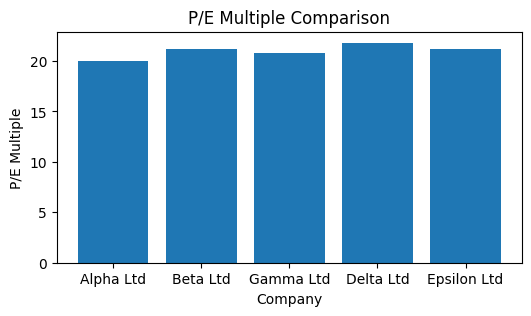

In [ ]:
#P/E Multiple Comparison

plt.figure(figsize=(6,3))
plt.bar(df["Company"],df["P/E"])
plt.title("P/E Multiple Comparison")
plt.xlabel("Company")
plt.ylabel("P/E Multiple")

plt.show()



*   This will show you which companies have the **highest and lowest P/E multiples**



---





##**Chart 2: EV/EBITDA Comparison**

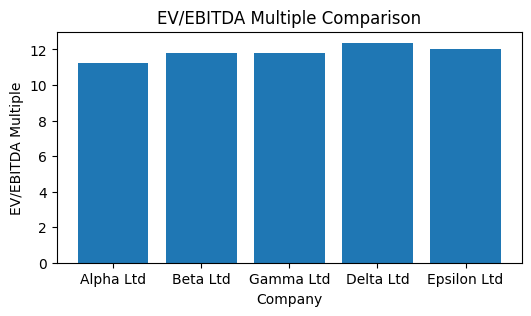

In [ ]:
#EV/EBITDA Multiple Comparison

plt.figure(figsize=(6,3))
plt.bar(df["Company"],df["EV/EBITDA"])
plt.title("EV/EBITDA Multiple Comparison")
plt.xlabel("Company")
plt.ylabel("EV/EBITDA Multiple")

plt.show()



---



##**Chart 3: EV/Revenue Comparison**

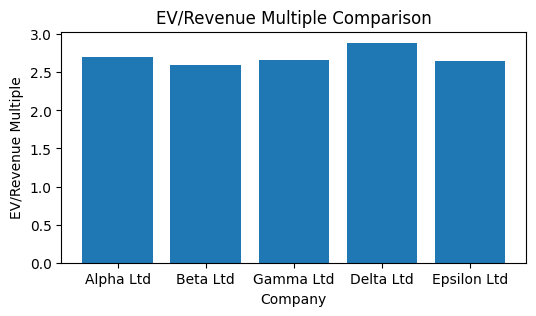

In [ ]:
#EV/Revenue Multiple Comparison

plt.figure(figsize=(6,3))
plt.bar(df["Company"],df["EV/Revenue"])
plt.title("EV/Revenue Multiple Comparison")
plt.xlabel("Company")
plt.ylabel("EV/Revenue Multiple")

plt.show()


# **Step 9 : Target Company vs. Peer Median**

---



We'll compare **Alpha Ltd** directly against the median of its peer group .

In [ ]:
#Compare Target Company with Peer Median

comparison = pd.DataFrame({
    "Metric":[
        "P/E",
        "EV/EBITDA",
        "EV/Revenue"
    ],
    "Alpha Ltd":[
        target["P/E"],
        target["EV/EBITDA"],
        target["EV/Revenue"]
    ],
    "Peer Median": [
        median_pe,
        median_ev_ebitda,
        median_ev_revenue
    ]

})

comparison

,Metric,Alpha Ltd,Peer Median
0,P/E,20.00,21.165158
1,EV/EBITDA,11.25,11.909091
2,EV/Revenue,2.70,2.654175


# **Step 10: Visualize Target vs. Peer Median**

---



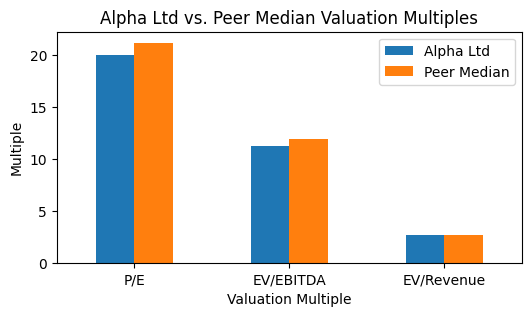

In [ ]:
#Target vs Peer Median

comparison_plot = comparison.set_index("Metric")

comparison_plot.plot(
    kind="bar",
    figsize=(6,3)
)

plt.title("Alpha Ltd vs. Peer Median Valuation Multiples")
plt.xlabel("Valuation Multiple")
plt.ylabel("Multiple")
plt.xticks(rotation=0)

plt.show()



*  This chart will let you quickly see whether **"Alpha Ltd" trades above or below its peer median** across the three valuation multiples.



#**Step 11: Automatically Analyze Alpha Ltd (Valuation Analysis)**

---



We'll calculate whether **Alpha Ltd** is trading at a **premium or discount** compared with its peers.

In [ ]:
#Analyze Target Company Valuation

print("Valuation Analysis for",target_company)
print("-"*60
      )

#P/E Analysis
if target["P/E"] > median_pe:
  print("P/E: Alpha Ltd. trades at a premium to its peers.")
else:
  print("P/E: Alpha Ltd trades at a discount to its peers.")

# EV/EBITDA Analysis
if target["EV/EBITDA"] > median_ev_ebitda:
    print("EV/EBITDA: Alpha Ltd trades at a premium to its peers.")
else:
    print("EV/EBITDA: Alpha Ltd trades at a discount to its peers.")

# EV/Revenue Analysis
if target["EV/Revenue"] > median_ev_revenue:
    print("EV/Revenue: Alpha Ltd trades at a premium to its peers.")
else:
    print("EV/Revenue: Alpha Ltd trades at a discount to its peers.")

Valuation Analysis for Alpha Ltd
------------------------------------------------------------
P/E: Alpha Ltd trades at a discount to its peers.
EV/EBITDA: Alpha Ltd trades at a discount to its peers.
EV/Revenue: Alpha Ltd trades at a premium to its peers.


##**What this does**


Python will automatically compare Alpha Ltd's:


*   P/E vs. Peer Median
*   EV/EBITDA vs. Peer Median


*   EV/Revenue vs. Peer Median

and tell you whether Alpha is trading at a **premium or discount**.

#**Conclusion**

---




The Comparable Companies Analysis indicates how Alpha Ltd is valued relative to its selected peer group.

The analysis compares Alpha Ltd using P/E, EV/EBITDA, and EV/Revenue multiples. The median valuation multiples of the peer group are used to estimate Alpha Ltd's implied valuation.

Alpha Ltd's valuation multiples are compared with the peer median to determine whether the company trades at a premium or discount to comparable companies.

This analysis demonstrates the use of relative valuation techniques commonly applied in equity research and investment banking.

### **Key Takeaways :**

- Comparable company analysis provides a market-based approach to valuation.
- Median peer multiples help reduce the impact of extreme valuation outliers.
- Different valuation multiples can produce different implied valuations.
- A company's premium or discount valuation may reflect differences in growth, profitability, risk, or market expectations.